# 8-3 깊이의 한계를 극복하는 덧셈의 마법 - ResNet

본 노트북은 8-3 절 본문의 [코드 8-11], [코드 8-12] 예제와, 본문이 코드를 싣지 않고 깃허브 노트북으로 미룬 배치 정규화 부작용 실험([표 8-6]·[표 8-7]·[그림 8-4]·[그림 8-6]), 그리고 [표 8-8] 비교를 포함한다.

다루는 내용
- 배치 정규화의 부작용 실험 - 미세한 입력 차이의 누적([표 8-6]·[표 8-7])
- 합성곱 계층별 기울기 코사인 유사도([그림 8-4])
- `[코드 8-11]` 잔차 블록 `ResidualBlock` 클래스
- `[코드 8-12]` 잔차 블록을 사용한 `MiniResNet` 클래스
- `[표 8-8]` MiniVGGNetBN 과 MiniResNet 의 학습·평가 결과 비교
- 잔차 학습 모델의 깊이별 기울기 유사도([그림 8-6])

## 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)

In [1]:
# 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)
# !pip install -q matplotlib numpy torch torchinfo torchvision

## 라이브러리 import 와 시드 고정

In [1]:
# 참고 - 환경 설정 (code_reference 모듈 임포트 경로와 시각화 설정)
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

common.set_korean_plot_env()
viz.configure(save_grayscale=False)

In [2]:
# 참고 - 라이브러리 import 와 시드 고정
SEED = 42
common.set_seed(SEED, deterministic=True)
# import copy
# import time
# import random

# import numpy as np
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import matplotlib.pyplot as plt
# import torch.nn.functional as F
# import torchinfo
# from torch.utils.data import DataLoader, random_split
# from torchvision import datasets, transforms

# SEED = 42
# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(SEED)

device = common.get_device()

CUDA를 사용합니다.


## 참고 - 배치 정규화의 부작용 실험

본문은 이 실험 코드를 싣지 않았지만, 훅과 모델 내부 계층 접근에 도움이 되므로 노트북에 포함한다. 합성곱 + 배치 정규화 조합을 12·48·96 개 가진 세 모델에 값이 같은 텐서와 미세하게 다른 텐서를 입력해 출력 차이를 본다.

In [3]:
# 참고 - 배치 정규화의 부작용을 실험하기 위한 모델
import torch.nn as nn

# 배치 정규화를 num_blocks회 반복하는 단순한 합성곱 모델
class StackedConvBN(nn.Module):
    def __init__(self, num_blocks, channels=16):
        super().__init__()
        # 첫 합성곱으로 채널 수를 channels로 맞춤
        layers = [
            nn.Conv2d(3, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
        ]

        # 이후 num_blocks - 1회 반복해 동일 채널 합성곱 + 배치 정규화 블록 추가
        for _ in range(num_blocks - 1):
            layers.append(
                nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            )
            layers.append(nn.BatchNorm2d(channels))
            layers.append(nn.ReLU())
        self.features = nn.Sequential(*layers)

    def forward(self, x):
        return self.features(x)

### [표 8-6]·[표 8-7] 값이 같은/거의 같은 두 텐서에 대한 출력 유사도

In [4]:
# 참고 - 두 입력에 대한 모델 출력의 유클리드 거리와 코사인 유사도

import torch
import torch.nn.functional as F

@torch.no_grad()
def measure_similarity(model, x_a, x_b):
    # 두 입력을 한 배치로 묶어 통과시킨다. 학습 모드의 배치 정규화가 배치
    # 단위 통계로 정규화하므로, 학습에서 배치마다 입력이 달라지는 상황과
    # 동일한 조건이 된다.
    model.train()
    outputs = model(torch.cat([x_a, x_b], dim=0))
    y_a = outputs[0].flatten()
    y_b = outputs[1].flatten()
    dist = (y_a - y_b).norm().item()
    cos = F.cosine_similarity(
        y_a.unsqueeze(0), y_b.unsqueeze(0),
    ).item()
    return dist, cos


# 입력 텐서 - 무작위 (1, 3, 32, 32)
torch.manual_seed(SEED)
test_input = torch.randn(1, 3, 32, 32)
same_input = test_input.clone()                 # 값이 같은 입력
# 소수점 여섯째 자리 이하만 다른 입력
near_input = test_input + 1e-5 * torch.randn_like(test_input)

# 세 모델 생성 (같은 초기 가중치)
torch.manual_seed(SEED)
conv_12 = StackedConvBN(12)
torch.manual_seed(SEED)
conv_48 = StackedConvBN(48)
torch.manual_seed(SEED)
conv_96 = StackedConvBN(96)
models = [conv_12, conv_48, conv_96]


def print_similarity_table(title, x_b):
    print(title)
    print(f'{"":>18s} | {"12 합성곱":>7s} | '
          f'{"48 합성곱":>7s} | {"96 합성곱":>7s}')
    print('-' * 60)
    results = [measure_similarity(m, test_input, x_b) for m in models]
    print(f'{"유클리드 거리":>12s} | ' + ' | '.join(
        f'{d:>10.6f}' for d, _ in results))
    print(f'{"코사인 유사도":>12s} | ' + ' | '.join(
        f'{c:>10.6f}' for _, c in results))


print_similarity_table(
    '[표 8-6] 값이 같은 두 텐서에 대한 출력 텐서의 모델별 유사도',
    same_input,
)
print()
print_similarity_table(
    '[표 8-7] 값이 거의 같은 두 텐서에 대한 출력 텐서의 모델별 유사도',
    near_input,
)

[표 8-6] 값이 같은 두 텐서에 대한 출력 텐서의 모델별 유사도
                   |  12 합성곱 |  48 합성곱 |  96 합성곱
------------------------------------------------------------
     유클리드 거리 |   0.000000 |   0.000000 |   0.000000
     코사인 유사도 |   1.000000 |   1.000000 |   1.000000

[표 8-7] 값이 거의 같은 두 텐서에 대한 출력 텐서의 모델별 유사도
                   |  12 합성곱 |  48 합성곱 |  96 합성곱
------------------------------------------------------------
     유클리드 거리 |   0.007275 |   3.609047 | 100.194923
     코사인 유사도 |   1.000000 |   0.999205 |   0.400111


### [그림 8-4] 합성곱 계층별 기울기 코사인 유사도

값이 거의 같은 두 입력에 대해 각 합성곱 계층의 가중치 기울기를 구한 뒤 계층별 코사인 유사도를 계산한다. 모델이 깊을수록 유사도가 무너진다.

In [5]:
# 참고 - 합성곱 계층별 기울기 코사인 유사도 측정
import numpy as np

def layer_grad_cosines(model, x_a, x_b):
    conv_layers = [m for m in model.modules()
                   if isinstance(m, nn.Conv2d)]

    def grads_for_input(x):
        for layer in conv_layers:
            layer.weight.grad = None
        out = model(x)
        # 전역 평균 풀링 후 합을 손실로 삼아 합성곱 기울기를 구함
        loss = F.adaptive_avg_pool2d(out, 1).flatten().sum()
        loss.backward()
        return [layer.weight.grad.flatten().clone()
                for layer in conv_layers]

    model.train()
    grads_a = grads_for_input(x_a)
    grads_b = grads_for_input(x_b)
    return [
        F.cosine_similarity(ga.unsqueeze(0), gb.unsqueeze(0)).item()
        for ga, gb in zip(grads_a, grads_b)
    ]


# 세 모델 재생성 (기울기 깨끗하게)
torch.manual_seed(SEED)
conv_12 = StackedConvBN(12)
torch.manual_seed(SEED)
conv_48 = StackedConvBN(48)
torch.manual_seed(SEED)
conv_96 = StackedConvBN(96)

cos_12 = layer_grad_cosines(conv_12, test_input, near_input)
cos_48 = layer_grad_cosines(conv_48, test_input, near_input)
cos_96 = layer_grad_cosines(conv_96, test_input, near_input)

print(f'12 합성곱: 코사인 평균 {np.mean(cos_12):.6f}, '
      f'최저 {min(cos_12):.6f}')
print(f'48 합성곱: 코사인 평균 {np.mean(cos_48):.6f}, '
      f'최저 {min(cos_48):.6f}')
print(f'96 합성곱: 코사인 평균 {np.mean(cos_96):.6f}, '
      f'최저 {min(cos_96):.6f}')

12 합성곱: 코사인 평균 0.999768, 최저 0.999664
48 합성곱: 코사인 평균 0.923123, 최저 0.898683
96 합성곱: 코사인 평균 0.063293, 최저 -0.133780


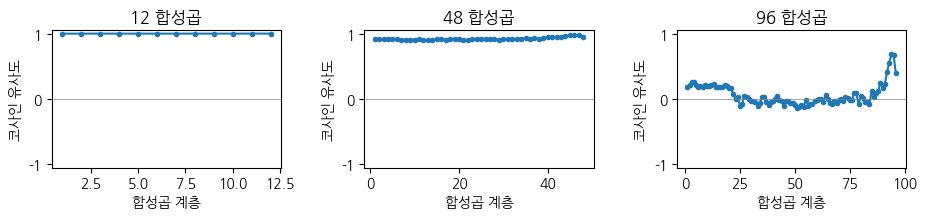

In [6]:
# [그림 8-4] - 합성곱 계층별 기울기 유사도 그래프
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(9.5, 2.3))
for ax, name, cos in [
    (axes[0], '12 합성곱', cos_12),
    (axes[1], '48 합성곱', cos_48),
    (axes[2], '96 합성곱', cos_96),
]:
    ax.plot(range(1, len(cos) + 1), cos, '-o', markersize=3)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_xlabel('합성곱 계층')
    ax.set_ylabel('코사인 유사도')
    ax.set_title(name)
    ax.set_ylim(-1.05, 1.05)
plt.tight_layout()
viz._save_grayscale(fig)
plt.show()

## 참고 - CIFAR-10 데이터로더 (8-1, 8-2 절과 동일)

In [8]:
"""
# 참고 - CIFAR-10 데이터로더 (5-3 절과 동일, 데이터 증강 미적용)

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch

# data_root: 데이터셋 다운로드 경로
data_root = '../../download'

# 데이터 변환 객체
CIFAR_MEAN = (0.5, 0.5, 0.5)
CIFAR_STD = (0.5, 0.5, 0.5)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# 데이터셋 생성
#    CIFAR-10 데이터셋의 훈련 데이터셋(50,000 샘플)을 4:1로 훈련, 검증 데이터셋으로 분리
full_set = datasets.CIFAR10(
    root=data_root, train=True,
    download=True, transform=transform,
)
test_set = datasets.CIFAR10(
    root=data_root, train=False,
    download=True, transform=transform,
)

TRAIN_SIZE, VALID_SIZE = 40000, 10000
train_set, valid_set = random_split(
    full_set, [TRAIN_SIZE, VALID_SIZE],
    generator=torch.Generator().manual_seed(SEED),
)

# 배치 크기 128인 데이터로더 생성
BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f'훈련/검증/평가 데이터셋: '
      f'{len(train_set)}/{len(valid_set)}/{len(test_set)}')
"""

"\n# 참고 - CIFAR-10 데이터로더 (5-3 절과 동일, 데이터 증강 미적용)\n\nfrom torchvision import datasets, transforms\nfrom torch.utils.data import DataLoader, random_split\nimport torch\n\n# data_root: 데이터셋 다운로드 경로\ndata_root = '../../download'\n\n# 데이터 변환 객체\nCIFAR_MEAN = (0.5, 0.5, 0.5)\nCIFAR_STD = (0.5, 0.5, 0.5)\ntransform = transforms.Compose([\n    transforms.ToTensor(),\n    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),\n])\n\n# 데이터셋 생성\n#    CIFAR-10 데이터셋의 훈련 데이터셋(50,000 샘플)을 4:1로 훈련, 검증 데이터셋으로 분리\nfull_set = datasets.CIFAR10(\n    root=data_root, train=True,\n    download=True, transform=transform,\n)\ntest_set = datasets.CIFAR10(\n    root=data_root, train=False,\n    download=True, transform=transform,\n)\n\nTRAIN_SIZE, VALID_SIZE = 40000, 10000\ntrain_set, valid_set = random_split(\n    full_set, [TRAIN_SIZE, VALID_SIZE],\n    generator=torch.Generator().manual_seed(SEED),\n)\n\n# 배치 크기 128인 데이터로더 생성\nBATCH_SIZE = 128\ntrain_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)\n

In [7]:
# 참고 - CIFAR-10 데이터로더 (5-3 절과 동일, 데이터 증강 적용)

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch

# data_root: 데이터셋 다운로드 경로
data_root = '../../download'

# 데이터 변환 객체
CIFAR_MEAN = (0.5, 0.5, 0.5)
CIFAR_STD = (0.5, 0.5, 0.5)

# 검증, 평가 데이터셋 데이터 변환 객체 (증강 없음)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# 훈련 데이터셋 데이터 변환 객체 (증강 추가)
train_transform = transforms.Compose([
    # 4 픽셀 패딩 후 32x32 크기로 무작위 자르기
    transforms.RandomCrop(32, padding=4),
    # 50% 확률로 좌우 반전
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# 데이터셋 생성
TRAIN_SIZE, VALID_SIZE = 40000, 10000       # 훈련/검증 데이터셋의 크기

# 같은 데이터셋으로 증강 변환 적용/미적용 데이터셋을 생성

# 증강 변환 적용: 훈련용으로 사용
train_full = datasets.CIFAR10(
    root=data_root, train=True,
    download=True, transform=train_transform,
)
# 증강 변환 미적용: 검증, 평가용으로 사용
valid_full = datasets.CIFAR10(
    root=data_root, train=True,
    download=True, transform=transform,
)

test_set = datasets.CIFAR10(
    root=data_root, train=False,
    download=True, transform=transform,
)

# 같은 기준으로 train_full과 valid_full을 분할해 훈련 데이터셋과 검증 데이터셋 생성
train_set, _ = random_split(train_full, [TRAIN_SIZE, VALID_SIZE], generator=torch.Generator().manual_seed(SEED))
# train_evaluate_set: 평가 시에는 증강 변환을 하지 않은 데이터셋 적용이 필요
train_evaluate_set, valid_set = random_split(valid_full, [TRAIN_SIZE, VALID_SIZE], generator=torch.Generator().manual_seed(SEED))

# 배치 크기 128인 데이터로더 생성
BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
train_evaluate_loader = DataLoader(train_evaluate_set, batch_size=BATCH_SIZE, shuffle=False)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f'훈련/검증/평가 데이터셋: '
      f'{len(train_set)}/{len(valid_set)}/{len(test_set)}')

훈련/검증/평가 데이터셋: 40000/10000/10000


In [10]:
# # 참고 - CIFAR-10 데이터로더 (5-3 절과 동일, 데이터 증강 미적용)
# # 외부 다운로드 데이터이므로 저장소 규약(§13.9)에 따라 download/ 에 받는다.
# CIFAR_MEAN = (0.5, 0.5, 0.5)
# CIFAR_STD = (0.5, 0.5, 0.5)
# transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
# ])

# full_set = datasets.CIFAR10(
#     root='../../download', train=True,
#     download=True, transform=transform,
# )
# test_set = datasets.CIFAR10(
#     root='../../download', train=False,
#     download=True, transform=transform,
# )

# TRAIN_SIZE, VALID_SIZE = 40000, 10000
# train_set, valid_set = random_split(
#     full_set, [TRAIN_SIZE, VALID_SIZE],
#     generator=torch.Generator().manual_seed(SEED),
# )

# BATCH_SIZE = 128
# train_loader = DataLoader(
#     train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0,
# )
# valid_loader = DataLoader(
#     valid_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
# )
# test_loader = DataLoader(
#     test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0,
# )
# print(f'훈련/검증/평가 데이터셋: '
#       f'{len(train_set)}/{len(valid_set)}/{len(test_set)}')

## [코드 8-11] 잔차 학습을 담당하는 잔차 블록을 정의하는 ResidualBlock 클래스

주 경로는 두 개의 합성곱 계층으로 잔차(`y - x`)를 학습하고, 지름길 경로는 입력을 그대로 전달한다. 채널 수가 바뀌는 경우에만 1x1 합성곱 + 배치 정규화 어댑터로 지름길의 형태를 맞춘다.

In [8]:
###############################################################################
# 코드 8-11 - 잔차 블록의 정의
###############################################################################
# 잔차 학습을 담당하는 잔차 블록 ResidualBlock 클래스
#     주 경로: 합성곱 -> 배치 정규화 -> ReLU -> 합성곱 -> 배치 정규화
#     지름길 경로: 항등 함수 nn.Identity()는 값을 건드리지 않고 그대로 통과시킴
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # 주 경로: x 를 입력받아 잔차(학습 결과로 y-x 에 수렴)를 출력
        self.main_path = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, 
                      bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, 
                      bias=False),
            nn.BatchNorm2d(out_channels),
        )               # (B, in_channels, ...) -> (B, out_channels, ...)
        # 지름길 경로: 입력을 그대로 전달하는 항등 함수 계층
        #              nn.Identity는 입력을 변환없이 출력하는 항등 함수 계층
        self.shortcut = nn.Identity()   
                        # (B, in_channels, ...) -> (B, in_channels, ...)
        # 어댑터: 입력 채널(in_channels)과 출력 채널(out_channels)이 다른 경우
        #         주 경로 결과와 지름길 경로 결과의 형태가 달라서 더할 수 없음
        #         이 경우에만 더할 수 있도록 지름길 경로의 결과를 변환
        if in_channels != out_channels:
            # 어댑터의 구조: 1x1 합성곱 계층(채널 수 변환) -> 배치 정규화 계층
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels, out_channels, kernel_size=1, bias=False,
                ),
                nn.BatchNorm2d(out_channels),
            )           # (B, in_channels, ...) -> (B, out_channels, ...)            
        # 최종 출력에 적용할 활성화 함수
        self.activation = nn.ReLU()

    def forward(self, x):
        # 주 경로가 학습한 잔차와 지름길 경로의 입력(x)을 더한 값이 
        # 최종 출력(y)이 되도록 학습하면 잔차가 입출력의 차이(y-x)로 수렴
        out = self.main_path(x) + self.shortcut(x)        
        out = self.activation(out)
        return out

## [코드 8-12] 잔차 블록을 사용해 만든 MiniResNet 클래스

MiniVGGNetBN 의 구조를 계승하면서 3개의 지름길을 더한다. 분류기는 평탄화 대신 전역 평균 풀링(`nn.AdaptiveAvgPool2d((1, 1))`)으로 특징 지도를 (128, 1, 1) 로 압축해 파라미터를 줄인다.

In [9]:
###############################################################################
# 코드 8-12 - 잔차 학습 방식으로 이미지를 분류하는 모델의 정의
###############################################################################
# 잔차 블록을 사용해 만든 MiniResNet 클래스
#     구조: (잔차 블록) * 3 -> 전역 평균 풀링 -> 완전 연결 계층(분류기)
class MiniResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # 잔차 계층 블록을 사용하는 특징 추출기
        self.features = nn.Sequential(
            ResidualBlock(3, 32),           # (3, 32, 32) -> (32, 32, 32)
            # kernel_size=2, stride=2의 최대 풀링
            nn.MaxPool2d(2, 2),             #             -> (32, 16, 16)
            ResidualBlock(32, 64),          #             -> (64, 16, 16)
            nn.MaxPool2d(2, 2),             #             -> (64, 8, 8)
            ResidualBlock(64, 128),         #             -> (128, 8, 8)
            nn.MaxPool2d(2, 2),             #             -> (128, 4, 4)
        )
        # 전역 평균 풀링                                  -> (128, 1, 1)
        self.pooling = nn.AdaptiveAvgPool2d((1, 1))  
        # 최종 분류기
        self.classifier = nn.Sequential(
            nn.Flatten(),                   #             -> (128,)
            nn.Linear(128, num_classes),    #             -> (10,)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pooling(x)
        x = self.classifier(x)
        return x

In [10]:
# 참고 - MiniResNet 모델 요약 정보
from torchinfo import summary

summary(MiniResNet(), input_size=(64, 3, 32, 32), device='cpu')

Layer (type:depth-idx)                   Output Shape              Param #
MiniResNet                               [64, 10]                  --
├─Sequential: 1-1                        [64, 128, 4, 4]           --
│    └─ResidualBlock: 2-1                [64, 32, 32, 32]          --
│    │    └─Sequential: 3-1              [64, 32, 32, 32]          10,208
│    │    └─Sequential: 3-2              [64, 32, 32, 32]          160
│    │    └─ReLU: 3-3                    [64, 32, 32, 32]          --
│    └─MaxPool2d: 2-2                    [64, 32, 16, 16]          --
│    └─ResidualBlock: 2-3                [64, 64, 16, 16]          --
│    │    └─Sequential: 3-4              [64, 64, 16, 16]          55,552
│    │    └─Sequential: 3-5              [64, 64, 16, 16]          2,176
│    │    └─ReLU: 3-6                    [64, 64, 16, 16]          --
│    └─MaxPool2d: 2-4                    [64, 64, 8, 8]            --
│    └─ResidualBlock: 2-5                [64, 128, 8, 8]           --
│  

## [표 8-8] MiniVGGNetBN 과 MiniResNet 의 학습 및 평가 결과 비교

In [14]:
# # 참고 - 비교용 MiniVGGNetBN 클래스 (8-2 절)
# class MiniVGGNetBN(nn.Module):
#     def __init__(self, num_classes=10):
#         super().__init__()
#         def vgg_block(in_channels, out_channels):
#             return nn.Sequential(
#                 nn.Conv2d(in_channels, out_channels, 3,
#                           padding=1, bias=False),
#                 nn.BatchNorm2d(out_channels),
#                 nn.ReLU(),
#                 nn.Conv2d(out_channels, out_channels, 3,
#                           padding=1, bias=False),
#                 nn.BatchNorm2d(out_channels),
#                 nn.ReLU(),
#                 nn.MaxPool2d(2, 2),
#             )
#         self.features = nn.Sequential(
#             vgg_block(3, 32), vgg_block(32, 64), vgg_block(64, 128),
#         )
#         self.classifier = nn.Sequential(
#             nn.Flatten(),
#             nn.Linear(128 * 4 * 4, 128),
#             nn.ReLU(),
#             nn.Linear(128, num_classes),
#         )

#     def forward(self, x):
#         x = self.features(x)
#         x = self.classifier(x)
#         return x

## 참고 - 학습/검증 함수와 조기 종료 학습 루프

In [15]:
# 참고 - 8장 모델 공통 학습 함수
import copy

# 1 에포크 학습 함수
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    loss_sum, sample_size = 0.0, 0
    for inputs, labels in train_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * inputs.size(0)
        sample_size += inputs.size(0)
    return loss_sum / sample_size

# 손실과 정확도를 반환하는 검증 함수
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, correct_size, sample_size = 0.0, 0, 0
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss_sum += loss.item() * inputs.size(0)
        correct_size += (outputs.argmax(dim=1) == labels).sum().item()
        sample_size += inputs.size(0)
    return loss_sum / sample_size, correct_size / sample_size

# 조기 종료 방식으로 모델을 학습하는 학습 함수
def train_with_early_stopping(model, train_loader, valid_loader,
                              criterion, optimizer, epochs, patience,
                              device):
    model.to(device)
    # 학습 로거 설정
    log = common.EpochLogger(epochs, target_rows=epochs)
    # 조기 종료 판단을 위한 변수 초기화
    best_valid_loss = float('inf')
    best_epoch = -1
    best_model_params = None
    patience_counter = 0
    # 학습 루프
    for epoch in range(1, epochs + 1):
        # 최적화
        train_loss = train_epoch(
            model, train_loader, criterion, optimizer, device,
        )
        # 검증
        valid_loss, valid_acc = evaluate(
            model, valid_loader, criterion, device,
        )
        # 학습 로그 저장 및 출력(정확도는 백분율로 저장)
        log.row(epoch, train_loss, valid_loss, valid_acc * 100)
        # 조기 종료 판단
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_epoch = epoch
            best_model_params = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
    # 최소 검증 손실 시점의 파라미터로 모델 복원
    if best_model_params is not None:
        print(f'최적 에포크({best_epoch}, 최소 검증 손실 {best_valid_loss:.4f})의 파라미터로 모델 복원')
        model.load_state_dict(best_model_params)    
    return log

In [16]:
# # 참고 - 학습/검증 함수와 조기 종료 학습 루프 (공통코드컨벤션 §7)
# def train_epoch(model, train_loader, criterion, optimizer, device):
#     """1 에포크 학습 - 가중 평균 손실을 반환."""
#     model.train()
#     loss_sum, sample_size = 0.0, 0
#     for inputs, labels in train_loader:
#         inputs = inputs.to(device)
#         labels = labels.to(device)
#         optimizer.zero_grad()
#         outputs = model(inputs)
#         loss = criterion(outputs, labels)
#         loss.backward()
#         optimizer.step()
#         loss_sum += loss.item() * inputs.size(0)
#         sample_size += inputs.size(0)
#     return loss_sum / sample_size


# @torch.no_grad()
# def evaluate(model, loader, criterion, device):
#     """검증/평가 손실과 정확도(0~1)를 반환."""
#     model.eval()
#     loss_sum, correct_size, sample_size = 0.0, 0, 0
#     for inputs, labels in loader:
#         inputs = inputs.to(device)
#         labels = labels.to(device)
#         outputs = model(inputs)
#         loss = criterion(outputs, labels)
#         loss_sum += loss.item() * inputs.size(0)
#         correct_size += (outputs.argmax(dim=1) == labels).sum().item()
#         sample_size += inputs.size(0)
#     return loss_sum / sample_size, correct_size / sample_size


# def train_with_early_stopping(model, train_loader, valid_loader,
#                               criterion, optimizer, epochs, patience,
#                               device):
#     """최저 검증 손실 모델을 보존하는 조기 종료 학습 루프(EpochLogger 표준).

#     전체 학습 시간·에포크당 시간·최적 에포크는 모두 학습 로그(log)가 들고 있다
#     (log.elapsed / log.seconds_per_epoch / log.best_epoch). 5-3 절과 같은 구조다.
#     """
#     model.to(device)
#     log = common.EpochLogger(epochs, target_rows=epochs)
#     best_valid_loss = float('inf')
#     best_model_params = None
#     patience_counter = 0
#     stopped_early = False
#     for epoch in range(1, epochs + 1):
#         train_loss = train_epoch(
#             model, train_loader, criterion, optimizer, device,
#         )
#         valid_loss, valid_acc = evaluate(
#             model, valid_loader, criterion, device,
#         )
#         # 정확도는 백분율 수(0~100)로 기록한다.
#         log.row(epoch, train_loss, valid_loss, valid_acc * 100)
#         if valid_loss < best_valid_loss:
#             best_valid_loss = valid_loss
#             best_model_params = copy.deepcopy(model.state_dict())
#             patience_counter = 0
#         else:
#             patience_counter += 1
#             if patience_counter >= patience:
#                 stopped_early = True
#                 break
#     # 최소 검증 손실 시점(log.best_epoch)의 파라미터로 모델 복원
#     model.load_state_dict(best_model_params)
#     log.summary(stopped='조기 종료' if stopped_early else None)
#     return log

In [ ]:
# 참고 - 학습 설정과 결과 정리/표 출력 헬퍼
EPOCHS = 200
PATIENCE = 10
LR = 1e-3
criterion = nn.CrossEntropyLoss()

# # 훈련 데이터셋의 손실·정확도 측정용 로더(셔플 없이 전체를 한 번 훑는다)
# train_eval_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=False)


# def collect_result(name, model, log):
#     """학습이 끝난 모델로 비교표 한 행에 필요한 값을 측정해 정리한다(측정만 한다)."""
#     train_loss, train_acc = evaluate(model, train_eval_loader, criterion, device)
#     _, test_acc = evaluate(model, test_loader, criterion, device)
#     return {
#         'name': name,
#         'best_epoch': log.best_epoch,
#         'elapsed': log.elapsed,
#         'seconds_per_epoch': log.seconds_per_epoch,
#         'train_loss': train_loss,
#         'valid_loss': log.best_value,
#         'train_acc': train_acc * 100,
#         'test_acc': test_acc * 100,
#         'train_curve': log.history['훈련 손실'],
#         'valid_curve': log.history['검증 손실'],
#     }


# def print_result_table(results, label_width=14):
#     header = (f'{"모델":>{label_width}s} | {"최적":>4s} | '
#              f'{"전체(초)":>8s} | {"에포크당":>8s} | '
#              f'{"훈련손실":>8s} | {"검증손실":>8s} | '
#              f'{"훈련%":>6s} | {"평가%":>6s}')
#     print(header)
#     print('-' * len(header))
#     for r in results:
#         print(f'{r["name"]:>{label_width}s} | {r["best_epoch"]:>4d} | '
#               f'{r["elapsed"]:>8.1f} | {r["seconds_per_epoch"]:>8.1f} | '
#               f'{r["train_loss"]:>8.4f} | {r["valid_loss"]:>8.4f} | '
#               f'{r["train_acc"]:>5.2f}% | {r["test_acc"]:>5.2f}%')

In [18]:
# # 참고 - 베이스라인 MiniVGGNetBN (8-2 절에서 학습·저장 - 재학습 없이 불러온다)
# model_vggbn = common.load_model(
#     MiniVGGNetBN(), 'checkpoints/mini_vggnet_bn.pt', device,
# )
# result_vggbn = torch.load(
#     'checkpoints/mini_vggnet_bn_result.pt', weights_only=False,
# )
# print(f'MiniVGGNetBN 불러옴 - 최적 {result_vggbn["best_epoch"]} 에포크, '
#       f'평가 정확도 {result_vggbn["test_acc"]:.2f}%')

MiniResNet 학습
  epoch    훈련 손실    검증 손실    정확도(%)     시간
  1/100       1.3434       1.1484       58.87%     0:11
  2/100       0.9706       1.1470       61.87%     0:23
  3/100       0.8147       0.8673       70.65%     0:34
  4/100       0.7194       0.7927       72.26%     0:45
  5/100       0.6472       0.8797       69.59%     0:56
  6/100       0.5933       0.7215       75.23%     1:08
  7/100       0.5552       0.7751       74.72%     1:21
  8/100       0.5141       0.6320       78.67%     1:33
  9/100       0.4950       0.6397       78.41%     1:45
 10/100       0.4719       0.5774       80.52%     1:58
 11/100       0.4508       0.6421       78.71%     2:10
 12/100       0.4333       0.5515       81.88%     2:21
 13/100       0.4115       0.5947       80.19%     2:34
 14/100       0.4007       0.4796       83.21%     2:45
 15/100       0.3805       0.5155       82.88%     2:56
 16/100       0.3671       0.6116       80.04%     3:09
 17/100       0.3569       0.5055       83.45% 

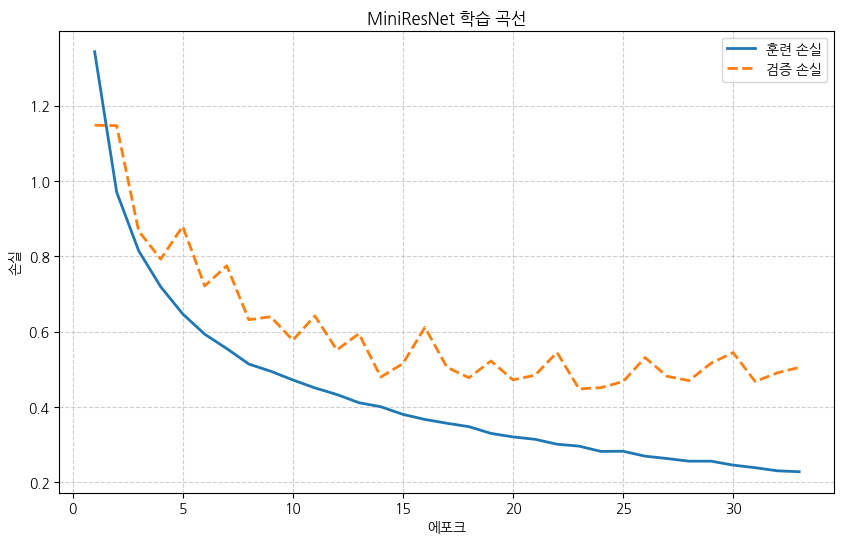

In [19]:
# 참고 - MiniResNet 학습
import torch.optim as optim

# 모델마다 결과 재현을 위해 학습 전에 시드 고정
common.set_seed(SEED, deterministic=True)

# MiniResNet 모델 객체를 생성하고 학습 장치로 이동
model_resnet = MiniResNet()
model_resnet.to(device)                               

# 옵티마이저
optimizer = optim.Adam(model_resnet.parameters(), lr=LR)

# 모델 학습
print('MiniResNet 학습')
log_resnet = train_with_early_stopping(
    model_resnet, train_loader, valid_loader, criterion, optimizer,
    EPOCHS, PATIENCE, device
)

log_resnet.plot(title='MiniResNet 학습 곡선', y_label='손실')

# torch.manual_seed(SEED)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(SEED)

# model_resnet = MiniResNet()
# model_resnet.to(device)
# optimizer = optim.Adam(model_resnet.parameters(), lr=LR)

# print('=== MiniResNet 학습 ===')
# log_resnet = train_with_early_stopping(
#     model_resnet, train_loader, valid_loader, criterion, optimizer,
#     EPOCHS, PATIENCE, device,
# )
# log_resnet.plot(title='MiniResNet 학습 곡선', y_label='손실')

# result_resnet = collect_result('MiniResNet', model_resnet, log_resnet)

In [20]:
# 참고 - MiniResNet 모델의 평가

train_loss, train_acc = evaluate(model_resnet, train_evaluate_loader, criterion, device)
test_loss, test_acc = evaluate(model_resnet, test_loader, criterion, device)
print('MiniResNet 모델 평가(훈련 데이터셋)')
print(f'훈련 손실: {train_loss:.4f}, 정확도: {train_acc * 100:.2f}%')
print(f'MiniResNet 모델 평가(평가 데이터셋)')
print(f'평가 손실: {test_loss:.4f}, 정확도: {test_acc * 100:.2f}%')

MiniResNet 모델 평가(훈련 데이터셋)
훈련 손실: 0.2714, 정확도: 90.47%
MiniResNet 모델 평가(평가 데이터셋)
평가 손실: 0.4647, 정확도: 84.79%


In [21]:
# # 참고 - [표 8-8] 결과 정리
# print_result_table([result_vggbn, result_resnet])

## 참고 - 두 모델의 학습 곡선 비교

공통코드컨벤션 §7.7에 따라 학습 곡선을 항상 그린다. 각 모델 `EpochLogger`가 보관한 손실 이력으로 MiniVGGNetBN 과 MiniResNet 의 수렴 양상을 비교한다.

In [22]:
# # 참고 - 두 모델의 학습 곡선 비교 (베이스라인도 저장된 곡선이 있어 함께 표시)
# viz.plot_histories(
#     {
#         'MiniVGGNetBN 훈련': result_vggbn['train_curve'],
#         'MiniVGGNetBN 검증': result_vggbn['valid_curve'],
#         'MiniResNet 훈련': result_resnet['train_curve'],
#         'MiniResNet 검증': result_resnet['valid_curve'],
#     },
#     title='MiniVGGNetBN vs MiniResNet 학습 곡선', y_label='손실',
# )

## 참고 - 더 깊은 신경망에서 잔차 학습의 효과 ([그림 8-6])

주 경로에 약 12·96·384 개의 합성곱 계층을 가진 잔차 학습 모델에서 거의 같은 두 입력에 대한 합성곱 계층별 기울기 유사도를 측정한다. 잔차 학습은 아주 깊은 모델에서도 1 에 가까운 코사인 유사도를 유지한다.

In [11]:
# 참고 - 잔차 학습으로 개선된 결과를 확인하는 실험을 위한 모델

# num_convs개의 합성곱 계층을 반복하는 단순한 잔차 학습 모델
class StackedResBlock(nn.Module):
    def __init__(self, num_convs, channels=16):
        super().__init__()
        layers = [
            nn.Conv2d(3, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
        ]
        # 각 잔차 블록이 합성곱 2개를 포함하므로 잔차 블록은 절반을 사용
        num_res_blocks = (num_convs - 1) // 2
        for _ in range(num_res_blocks):
            layers.append(ResidualBlock(channels, channels))
        self.features = nn.Sequential(*layers)

    def forward(self, x):
        return self.features(x)

In [12]:
# 참고 - 잔차 모델의 합성곱 계층별 기울기 코사인 유사도
torch.manual_seed(SEED)
res_12 = StackedResBlock(num_convs=12)
torch.manual_seed(SEED)
res_96 = StackedResBlock(num_convs=96)
torch.manual_seed(SEED)
res_384 = StackedResBlock(num_convs=384)

cos_r12 = layer_grad_cosines(res_12, test_input, near_input)
cos_r96 = layer_grad_cosines(res_96, test_input, near_input)
cos_r384 = layer_grad_cosines(res_384, test_input, near_input)

print(f'잔차 12 합성곱: 평균 {np.mean(cos_r12):.6f}, '
      f'최저 {min(cos_r12):.6f}')
print(f'잔차 96 합성곱: 평균 {np.mean(cos_r96):.6f}, '
      f'최저 {min(cos_r96):.6f}')
print(f'잔차 384 합성곱: 평균 {np.mean(cos_r384):.6f}, '
      f'최저 {min(cos_r384):.6f}')

잔차 12 합성곱: 평균 1.000000, 최저 1.000000
잔차 96 합성곱: 평균 0.999834, 최저 0.999613
잔차 384 합성곱: 평균 0.999835, 최저 0.999472


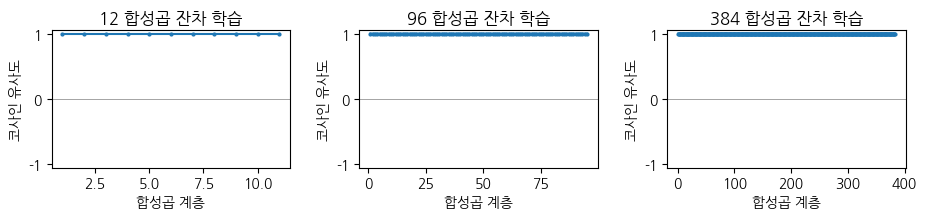

In [13]:
# [그림 8-6] - 잔차 학습 모델의 합성곱 계층별 기울기 유사도 그래프
fig, axes = plt.subplots(1, 3, figsize=(9.5, 2.3))
for ax, name, cos in [
    (axes[0], '12 합성곱 잔차 학습', cos_r12),
    (axes[1], '96 합성곱 잔차 학습', cos_r96),
    (axes[2], '384 합성곱 잔차 학습', cos_r384),
]:
    ax.plot(range(1, len(cos) + 1), cos, '-o', markersize=2)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_xlabel('합성곱 계층')
    ax.set_ylabel('코사인 유사도')
    ax.set_title(name)
    ax.set_ylim(-1.05, 1.05)
plt.tight_layout()
viz._save_grayscale(fig)
plt.show()

## 정리

- 배치 정규화 계층이 많아지면 미세한 입력 차이가 누적되어 깊은 모델의 출력과 기울기 방향이 크게 흔들린다([표 8-7]·[그림 8-4]).
- ResNet 의 잔차 학습은 계층 블록이 입력과 출력의 차이(잔차)만 학습하고, 지름길 경로로 입력을 그대로 전달한다. 이 덕분에 순전파의 정보 왜곡과 역전파의 기울기 소실을 함께 막는다.
- MiniResNet 은 MiniVGGNetBN 과 본질적 구조가 같아 성능 차이는 크지 않지만([표 8-8]), 잔차 학습 모델은 합성곱 384 개의 아주 깊은 모델에서도 기울기 유사도를 1 에 가깝게 유지한다([그림 8-6]).

In [26]:
a = b

#---- 추가 테스트 ----#
# 코드 8-12 - 잔차 블록을 사용해 만든 MiniResNet 클래스
# (잔차 블록) * 3 -> 전역 평균 풀링 -> 완전 연결(분류기)
class MiniResNet_2(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # 잔차 계층 블록을 사용하는 특징 추출기
        self.features = nn.Sequential(
            ResidualBlock(3, 32),                   # (3, 32, 32)->(32, 32, 32)
            nn.MaxPool2d(kernel_size=2, stride=2),  # -> (32, 16, 16)
            ResidualBlock(32, 64),                  # -> (64, 16, 16)
            nn.MaxPool2d(kernel_size=2, stride=2),  # -> (64, 8, 8)
            ResidualBlock(64, 128),                 # -> (128, 8, 8)
            nn.MaxPool2d(kernel_size=2, stride=2),  # -> (128, 4, 4)
            ResidualBlock(128, 256),                 # -> (256, 4, 4)
            nn.MaxPool2d(kernel_size=2, stride=2),  # -> (256, 2, 2)

        )
        # 전역 평균 풀링
        self.pooling = nn.AdaptiveAvgPool2d((1, 1))  # (256, 2, 2)->(256, 1, 1)
        # 최종 분류기
        self.classifier = nn.Sequential(
            nn.Flatten(),                   # (256, 1, 1) -> (256,)
            nn.Dropout(0.5),                   # 과적합 방지용 드롭아웃 추가
            nn.Linear(256, num_classes),    # (256,) -> (10,)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pooling(x)
        x = self.classifier(x)
        return x

class MiniResNet_3(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # 잔차 계층 블록을 사용하는 특징 추출기
        self.features = nn.Sequential(
            ResidualBlock(3, 32),                   # (3, 32, 32)->(32, 32, 32)
            ResidualBlock(32, 32),                   # (3, 32, 32)->(32, 32, 32)
            nn.MaxPool2d(kernel_size=2, stride=2),  # -> (32, 16, 16)
            ResidualBlock(32, 64),                  # -> (64, 16, 16)
            ResidualBlock(64, 64),                  # -> (64, 16, 16)
            nn.MaxPool2d(kernel_size=2, stride=2),  # -> (64, 8, 8)
            ResidualBlock(64, 128),                 # -> (128, 8, 8)
            ResidualBlock(128, 128),                 # -> (128, 8, 8)
            nn.MaxPool2d(kernel_size=2, stride=2),  # -> (128, 4, 4)
        )
        # 전역 평균 풀링
        self.pooling = nn.AdaptiveAvgPool2d((1, 1))  # (128, 4, 4)->(128, 1, 1)
        # 최종 분류기
        self.classifier = nn.Sequential(
            nn.Flatten(),                   # (128, 1, 1) -> (128,)
            nn.Dropout(0.5),                   # 과적합 방지용 드롭아웃 추가
            nn.Linear(128, num_classes),    # (128,) -> (10,)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pooling(x)
        x = self.classifier(x)
        return x

class MiniResNet_4(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # 잔차 계층 블록을 사용하는 특징 추출기
        self.features = nn.Sequential(
            ResidualBlock(3, 32),                   # (3, 32, 32)->(32, 32, 32)
            nn.MaxPool2d(kernel_size=2, stride=2),  # -> (32, 16, 16)
            ResidualBlock(32, 64),                  # -> (64, 16, 16)
            nn.MaxPool2d(kernel_size=2, stride=2),  # -> (64, 8, 8)
            ResidualBlock(64, 128),                 # -> (128, 8, 8)
            nn.MaxPool2d(kernel_size=2, stride=2),  # -> (128, 4, 4)
        )
        # 전역 평균 풀링
        self.pooling = nn.AdaptiveAvgPool2d((1, 1))  # (128, 4, 4)->(128, 1, 1)
        # 최종 분류기
        self.classifier = nn.Sequential(
            nn.Flatten(),                   # (128, 1, 1) -> (128,)
            nn.Dropout(0.5),                   # 과적합 방지용 드롭아웃 추가
            nn.Linear(128, num_classes),    # (128,) -> (10,)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pooling(x)
        x = self.classifier(x)
        return x


LR = 1e-3
   
EPOCHS = 50
PATIENCE = 10
torch.manual_seed(SEED)
model_resnet_2 = MiniResNet_2().to(device)
optimizer = optim.Adam(model_resnet_2.parameters(), lr=LR)
print('=== MiniResNet_2 학습 ===')
log_resnet_2 = train_with_early_stopping(
    model_resnet_2, train_loader, valid_loader, criterion, optimizer,
    EPOCHS, PATIENCE, device,
)
log_resnet_2.plot(title='MiniResNet_2 학습 곡선', y_label='손실')    
result_resnet_2 = collect_result('MiniResNet_2', model_resnet_2, log_resnet_2)

torch.manual_seed(SEED)
model_resnet_3 = MiniResNet_3().to(device)
optimizer = optim.Adam(model_resnet_3.parameters(), lr=LR)
print('=== MiniResNet_3 학습 ===')
log_resnet_3 = train_with_early_stopping(
    model_resnet_3, train_loader, valid_loader, criterion, optimizer,
    EPOCHS, PATIENCE, device,
)
log_resnet_3.plot(title='MiniResNet_3 학습 곡선', y_label='손실')    
result_resnet_3 = collect_result('MiniResNet_3', model_resnet_3, log_resnet_3)

torch.manual_seed(SEED)
model_resnet_4 = MiniResNet_4().to(device)
optimizer = optim.Adam(model_resnet_4.parameters(), lr=LR)
print('=== MiniResNet_4 학습 ===')
log_resnet_4 = train_with_early_stopping(
    model_resnet_4, train_loader, valid_loader, criterion, optimizer,
    EPOCHS, PATIENCE, device,
)
log_resnet_4.plot(title='MiniResNet_4 학습 곡선', y_label='손실')    
result_resnet_4 = collect_result('MiniResNet_4', model_resnet_4, log_resnet_4)


NameError: name 'b' is not defined

In [ ]:
# 참고 - [표 8-2] 결과 정리
def print_result_table(results, label_width=12):
    header = (f'{"모델":>{label_width}s} | {"최적":>4s} | '
             f'{"전체(초)":>8s} | {"에포크당":>8s} | '
             f'{"훈련손실":>8s} | {"검증손실":>8s} | '
             f'{"훈련%":>6s} | {"평가%":>6s}')
    print(header)
    print('-' * len(header))
    for r in results:
        print(f'{r["name"]:>{label_width}s} | {r["best_epoch"]:>4d} | '
              f'{r["elapsed"]:>8.1f} | {r["seconds_per_epoch"]:>8.1f} | '
              f'{r["train_loss"]:>8.4f} | {r["valid_loss"]:>8.4f} | '
              f'{r["train_acc"]:>5.2f}% | {r["test_acc"]:>5.2f}%')


print_result_table([result_resnet_2, result_resnet_3, result_resnet_4])